In [108]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import seaborn as sns
from sklearn.metrics import confusion_matrix

In [170]:
# Human Version

vitya = pd.read_csv('../data/labeling/vitya_def.csv')
alina = pd.read_csv('../data/labeling/alina_def.csv')
kate = pd.read_csv('../data/labeling/test_output_def_kate.csv')
ira = pd.read_csv('../data/labeling/test_output_ira_def.csv')

def rename_assessor_columns(df):
    df.columns = df.columns.str.replace(r'assessor_.*', 'result', regex=True)
    return df

# Apply the renaming to each dataframe
vitya = rename_assessor_columns(vitya)
alina = rename_assessor_columns(alina)
kate = rename_assessor_columns(kate)
ira = rename_assessor_columns(ira)

# Concatenate dataframes by rows
combined_df = pd.concat([vitya, alina, kate, ira], ignore_index=True)

In [100]:
# # GPT Version
# gpt_def = pd.read_csv('../data/main_gpt4_nodef.csv')

# for i, row in gpt_def.iterrows():
#     if row['gpt4'] == 'no such image':
#         if row['model_a'] == 'retrieval':
#             gpt_def['gpt4'][i] = 'B'
#         else:
#             gpt_def['gpt4'][i] = 'A'

# gpt_def['result'] = gpt_def['gpt4'].replace({'A': 0, 'B': 1, 'C': 2, 'D': 3})
# combined_df = gpt_def

/tmp/ipykernel_3712862/1773457887.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gpt_def['gpt4'][i] = 'A'
/tmp/ipykernel_3712862/1773457887.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gpt_def['gpt4'][i] = 'B'


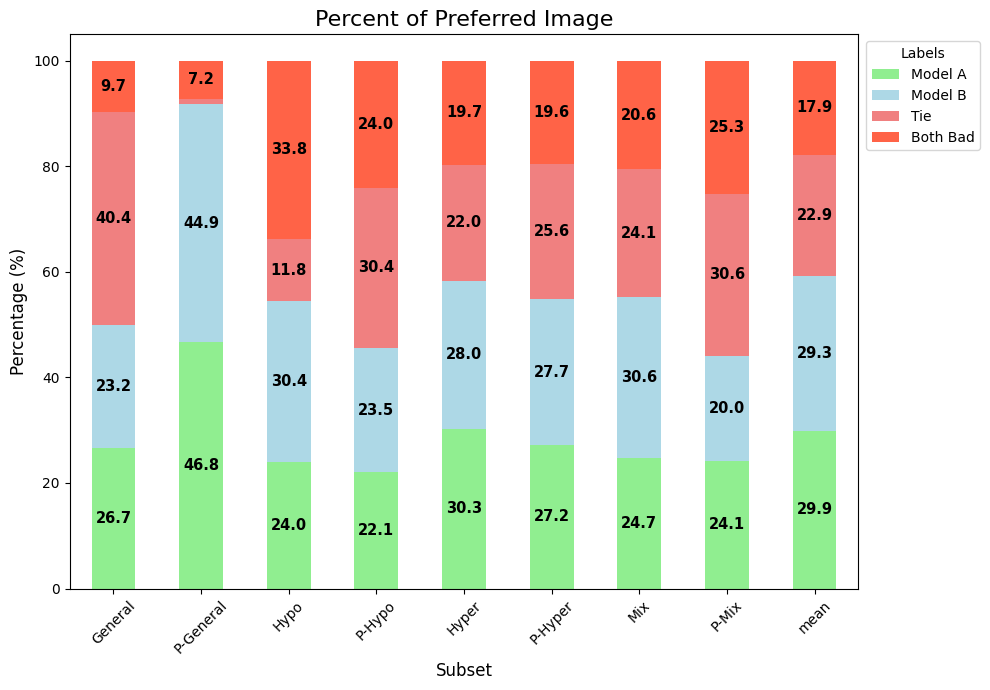

In [177]:
result_counts = combined_df['result'].value_counts()

# Second visualization: Frequency of 'result' grouped by 'subset'
result_grouped = combined_df.groupby('subset')['result'].value_counts().unstack()

result_grouped.loc['mean'] = result_counts #/ result_counts.sum()


# Calculate the frequency of each label as a percentage of the subset total
result_grouped_percent = result_grouped.div(result_grouped.sum(axis=1), axis=0) * 100

label_mapping = {0: 'Model A', 1: 'Model B', 2: 'Tie', 3: 'Both Bad'}
result_grouped_percent.rename(columns=label_mapping, inplace=True)

subset_rename_mapping = {
    'appendix': 'General',
    'appendix_llama': 'P-General',
    'leafs_and_no_leafs': 'Hypo',
    'leafs_and_no_leafs_llama': 'P-Hypo',
    'predict_hypernym': 'Hyper',
    'predict_hypernym_llama': 'P-Hyper',
    'simple_triplet_2parent': 'Mix',
    'simple_triplet_2parent_llama': 'P-Mix',
    'mean': 'mean'
}

# Rename the index (subset) in the grouped dataframe
result_grouped_percent.rename(index=subset_rename_mapping, inplace=True)

color_palette = {
    'Model A': 'lightgreen',   # 0 (light green)
    'Model B': 'lightblue',    # 1 (light blue)
    'Tie': 'lightcoral',       # 2 (light red)
    'Both Bad': 'tomato'       # 3 (lighter red)
}

# Plot the updated grouped data as percentages with the new labels and custom colors
ax = result_grouped_percent.plot(kind='bar', stacked=True, figsize=(10, 7), color=[color_palette[col] for col in result_grouped_percent.columns])

# Add percentage text on each bar slice
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    if height > 5:  # Avoid showing text on small patches
        ax.text(x + width/2, y + height/2, f'{height:.1f}', ha='center', va='center', fontsize=10.5, rotation=0, weight='bold')

# Final plot adjustments
plt.title('Percent of Preferred Image', fontsize=16)
plt.xlabel('Subset', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Labels', bbox_to_anchor=(1.001, 1), loc='upper left')  # Adjusted position
plt.tight_layout()
plt.show()

In [102]:
#combined_df.to_csv('../data/labeling/gpt_nodef.csv', index=False)

/tmp/ipykernel_3712862/2224809714.py:13: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.errorbar(models, scores, yerr=ci_adjusted, fmt='o', ecolor='gray', capsize=8, linestyle='', color='teal',


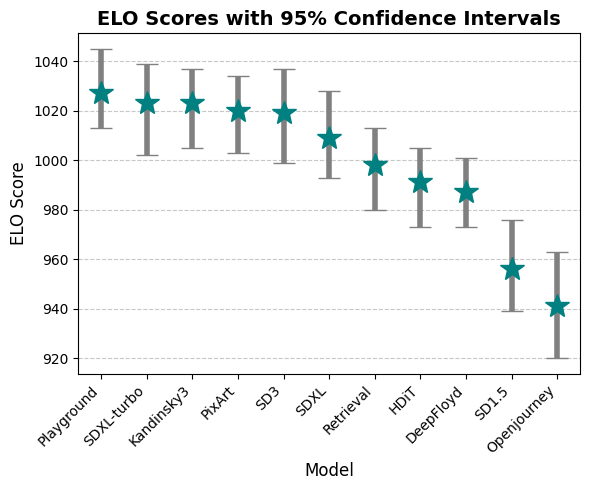

In [191]:


# Human no def for visualization
models = ['Playground', 'SDXL-turbo', 'Kandinsky3', 'PixArt', 'SD3', 'SDXL', 'Retrieval', 
          'HDiT', 'DeepFloyd', 'SD1.5', 'Openjourney']
scores = [1027, 1023, 1023, 1020, 1019, 1009, 998, 991, 987, 956, 941]
ci_lower = [-18, -16, -14, -14, -18, -19, -15, -14, -14, -20, -22]
ci_upper = [14, 21, 18, 17, 20, 16, 18, 18, 14, 17, 21]

ci_adjusted = np.array([ci_upper, np.abs(ci_lower)])

# Create the plot again with the adjusted CI
plt.figure(figsize=(6, 5))
# Plot using a color scheme with distinct colors and thicker error bars for better visualization
plt.errorbar(models, scores, yerr=ci_adjusted, fmt='o', ecolor='gray', capsize=8, linestyle='', color='teal', 
             marker='*', markersize=18, elinewidth=4)



# Add labels and title with enhanced font sizes
plt.title('ELO Scores with 95% Confidence Intervals', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('ELO Score', fontsize=12)

# Reduce the space between the points on x-axis and style ticks
plt.xticks(rotation=45, ha='right', fontsize=10)

# Add gridlines for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot with tighter layout
plt.tight_layout()
plt.show()

/tmp/ipykernel_3712862/626191904.py:16: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.errorbar(models, scores, yerr=ci_adjusted, fmt='o', ecolor='gray', capsize=10, linestyle='', color='blue',


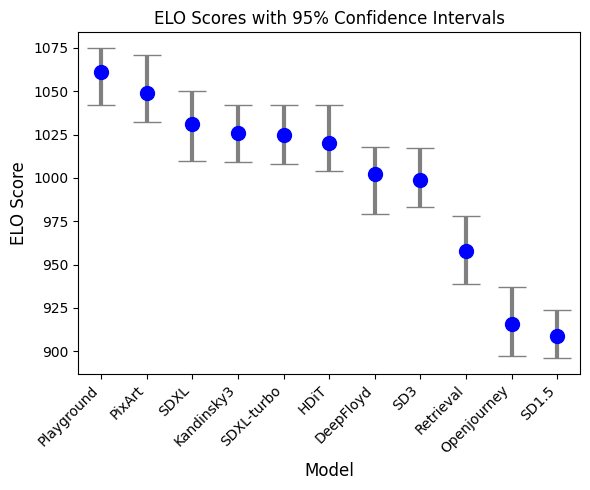

In [81]:

# Human def
models = ['Playground', 'PixArt', 'SDXL', 'Kandinsky3', 'SDXL-turbo', 'HDiT', 'DeepFloyd', 
          'SD3', 'Retrieval', 'Openjourney', 'SD1.5']
scores = [1061, 1049, 1031, 1026, 1025, 1020, 1002, 999, 958, 916, 909]
ci_lower = [-14, -22, -19, -16, -17, -22, -16, -18, -20, -21, -15]
ci_upper = [19, 17, 21, 17, 17, 16, 23, 16, 19, 19, 13]



ci_adjusted = np.array([ci_upper, np.abs(ci_lower)])

# Create the plot again with the adjusted CI
plt.figure(figsize=(6, 5))

# Plot with thicker lines and a larger marker for the mean
plt.errorbar(models, scores, yerr=ci_adjusted, fmt='o', ecolor='gray', capsize=10, linestyle='', color='blue', 
             marker='o', markersize=10, elinewidth=3)

# Add labels and title
plt.title('ELO Scores with 95% Confidence Intervals', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylabel('ELO Score', fontsize=12)

# Reduce the space between the points on x-axis
plt.xticks(rotation=45, ha='right')

#plt.xlim(-0.5, len(models) - 0.5)


# Display the plot
plt.tight_layout()
plt.show()

/tmp/ipykernel_3712862/1504133846.py:16: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.errorbar(models, scores, yerr=ci_adjusted, fmt='o', ecolor='gray', capsize=10, linestyle='', color='blue',


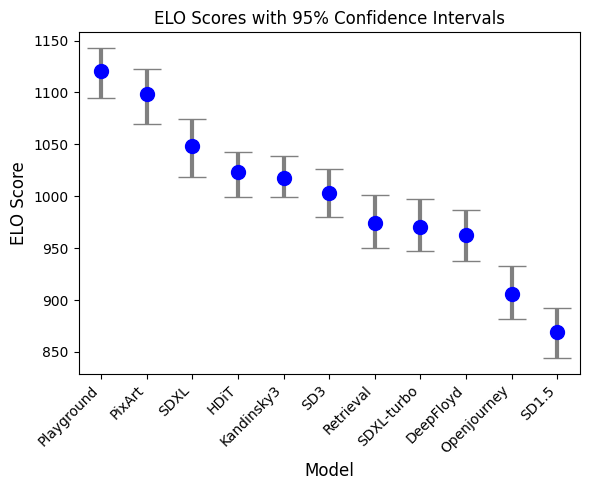

In [103]:
# gpt4 def
models = ['Playground', 'PixArt', 'SDXL', 'HDiT', 'Kandinsky3', 'SD3', 'Retrieval', 
          'SDXL-turbo', 'DeepFloyd', 'Openjourney', 'SD1.5']

scores = [1121, 1099, 1048, 1023, 1018, 1003, 974, 970, 963, 906, 869]

ci_lower = [-22, -24, -26, -20, -21, -23, -27, -27, -24, -27, -23]

ci_upper = [26, 29, 29, 24, 19, 23, 24, 23, 25, 24, 25]

ci_adjusted = np.array([ci_upper, np.abs(ci_lower)])

# Create the plot again with the adjusted CI
plt.figure(figsize=(6, 5))

# Plot with thicker lines and a larger marker for the mean
plt.errorbar(models, scores, yerr=ci_adjusted, fmt='o', ecolor='gray', capsize=10, linestyle='', color='blue', 
             marker='o', markersize=10, elinewidth=3)

# Add labels and title
plt.title('ELO Scores with 95% Confidence Intervals', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylabel('ELO Score', fontsize=12)

# Reduce the space between the points on x-axis
plt.xticks(rotation=45, ha='right')

#plt.xlim(-0.5, len(models) - 0.5)


# Display the plot
plt.tight_layout()
plt.show()

/tmp/ipykernel_3712862/2120160522.py:17: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.errorbar(models, scores, yerr=ci_adjusted, fmt='o', ecolor='gray', capsize=10, linestyle='', color='blue',


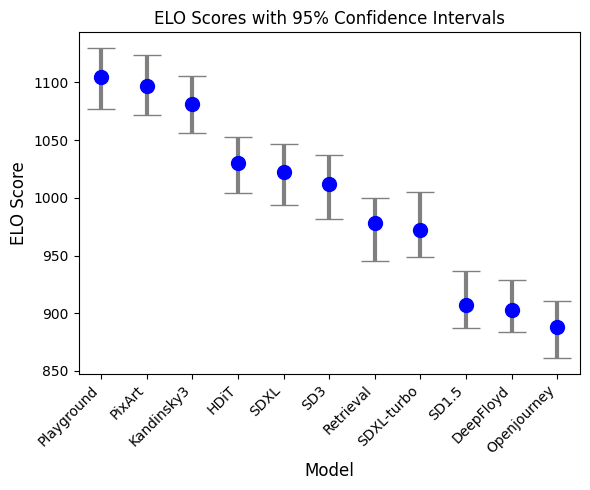

In [104]:

# GPT no def
models = ['Playground', 'PixArt', 'Kandinsky3', 'HDiT', 'SDXL', 'SD3', 'Retrieval', 
          'SDXL-turbo', 'SD1.5', 'DeepFloyd', 'Openjourney']

scores = [1105, 1097, 1081, 1030, 1022, 1012, 978, 972, 907, 903, 888]

ci_lower = [-25, -27, -25, -23, -25, -25, -22, -33, -30, -26, -23]

ci_upper = [28, 25, 25, 26, 28, 30, 33, 23, 20, 19, 27]

ci_adjusted = np.array([ci_upper, np.abs(ci_lower)])

# Create the plot again with the adjusted CI
plt.figure(figsize=(6, 5))

# Plot with thicker lines and a larger marker for the mean
plt.errorbar(models, scores, yerr=ci_adjusted, fmt='o', ecolor='gray', capsize=10, linestyle='', color='blue', 
             marker='o', markersize=10, elinewidth=3)

# Add labels and title
plt.title('ELO Scores with 95% Confidence Intervals', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylabel('ELO Score', fontsize=12)

# Reduce the space between the points on x-axis
plt.xticks(rotation=45, ha='right')

#plt.xlim(-0.5, len(models) - 0.5)


# Display the plot
plt.tight_layout()
plt.show()

In [129]:
# Human Version

vitya = pd.read_csv('../data/labeling/vitya_def.csv')
alina = pd.read_csv('../data/labeling/alina_def.csv')
kate = pd.read_csv('../data/labeling/test_output_def_kate.csv')
ira = pd.read_csv('../data/labeling/test_output_ira_def.csv')

def rename_assessor_columns(df):
    df.columns = df.columns.str.replace(r'assessor_.*', 'result', regex=True)
    return df

# Apply the renaming to each dataframe
vitya = rename_assessor_columns(vitya)
alina = rename_assessor_columns(alina)
kate = rename_assessor_columns(kate)
ira = rename_assessor_columns(ira)

# Concatenate dataframes by rows
human = pd.concat([vitya, alina, kate, ira], ignore_index=True)

# GPT Version
gpt_def = pd.read_csv('../data/main_gpt4_def-2.csv')

for i, row in gpt_def.iterrows():
    if row['gpt4'] == 'no such image':
        if row['model_a'] == 'retrieval':
            gpt_def['gpt4'][i] = 'B'
        else:
            gpt_def['gpt4'][i] = 'A'

gpt_def['result'] = gpt_def['gpt4'].replace({'A': 0, 'B': 1, 'C': 2, 'D': 3})
gpt = gpt_def
gpt['result'][gpt['result'].isna()] = 3


/tmp/ipykernel_3712862/3949825675.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gpt_def['gpt4'][i] = 'A'
/tmp/ipykernel_3712862/3949825675.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gpt_def['gpt4'][i] = 'B'
/tmp/ipykernel_3712862/3949825675.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gpt['result'][gpt['result'].isna()] = 3


In [130]:
# Pearson correlation (just for reference, not recommended for discrete data)
pearson_corr = human['result'].corr(gpt['result'], method='pearson')

# Spearman rank correlation (recommended)
spearman_corr = human['result'].corr(gpt['result'], method='spearman')

# Kendall Tau correlation (also suitable for ordinal data)
kendall_corr = human['result'].corr(gpt['result'], method='kendall')

# Display results
print(f"Pearson correlation: {pearson_corr}")
print(f"Spearman correlation: {spearman_corr}")
print(f"Kendall Tau correlation: {kendall_corr}")

Pearson correlation: 0.05573125580420654
Spearman correlation: 0.05062638086846596
Kendall Tau correlation: 0.04621135860265836


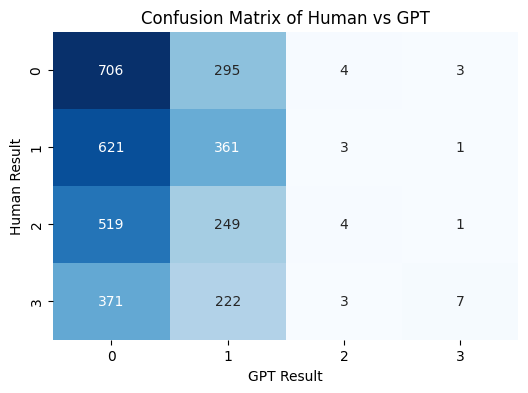

In [136]:
# Compute confusion matrix
conf_matrix = confusion_matrix(human['result'], gpt['result'])

# Plot the heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix of Human vs GPT')
plt.xlabel('GPT Result')
plt.ylabel('Human Result')
plt.show()

In [137]:
mask = (human['result'] == 0) | (human['result'] == 1)

# Filter both human and gpt dataframes based on this condition
human_filtered = human[mask]
gpt_filtered = gpt[mask]

# Calculate correlations on filtered data
pearson_corr_filtered = human_filtered['result'].corr(gpt_filtered['result'], method='pearson')
spearman_corr_filtered = human_filtered['result'].corr(gpt_filtered['result'], method='spearman')
kendall_corr_filtered = human_filtered['result'].corr(gpt_filtered['result'], method='kendall')

# Display results
print(f"Pearson correlation (human 0 or 1): {pearson_corr_filtered}")
print(f"Spearman correlation (human 0 or 1): {spearman_corr_filtered}")
print(f"Kendall Tau correlation (human 0 or 1): {kendall_corr_filtered}")

Pearson correlation (human 0 or 1): 0.06651511398803168
Spearman correlation (human 0 or 1): 0.07324950137752571
Kendall Tau correlation (human 0 or 1): 0.07305099241077298


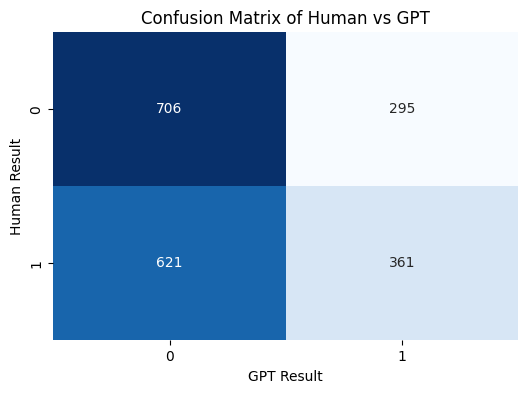

In [139]:
# Compute confusion matrix
conf_matrix = confusion_matrix(human_filtered['result'], gpt_filtered['result'])

# Plot the heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix[:2,:2], annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix of Human vs GPT')
plt.xlabel('GPT Result')
plt.ylabel('Human Result')
plt.show()

In [142]:
# Human Version

vitya = pd.read_csv('../data/labeling/vitya_def.csv')
alina = pd.read_csv('../data/labeling/alina_def.csv')
kate = pd.read_csv('../data/labeling/test_output_def_kate.csv')
ira = pd.read_csv('../data/labeling/test_output_ira_def.csv')

def rename_assessor_columns(df):
    df.columns = df.columns.str.replace(r'assessor_.*', 'result', regex=True)
    return df

# Apply the renaming to each dataframe
vitya = rename_assessor_columns(vitya)
alina = rename_assessor_columns(alina)
kate = rename_assessor_columns(kate)
ira = rename_assessor_columns(ira)

# Concatenate dataframes by rows
wdef = pd.concat([vitya, alina, kate, ira], ignore_index=True)


vitya = pd.read_csv('../data/labeling/vitya.csv')
alina = pd.read_csv('../data/labeling/alina.csv')
kate = pd.read_csv('../data/labeling/test_output_kate.csv')
ira = pd.read_csv('../data/labeling/test_output_ira.csv')

def rename_assessor_columns(df):
    df.columns = df.columns.str.replace(r'assessor_.*', 'result', regex=True)
    return df

# Apply the renaming to each dataframe
vitya = rename_assessor_columns(vitya)
alina = rename_assessor_columns(alina)
kate = rename_assessor_columns(kate)
ira = rename_assessor_columns(ira)

# Concatenate dataframes by rows
no_def = pd.concat([vitya, alina, kate, ira], ignore_index=True)

In [148]:
# Check for equality between the two DataFrames
comparison_df = pd.DataFrame({
    'wdef_result': wdef['result'],
    'no_def_result': no_def['result'],
    'change': wdef['result'] == no_def['result']
})

# Categorize the changes: 'Same' if equal, 'Changed' if different
comparison_df['status'] = comparison_df['change'].apply(lambda x: 'Same' if x else 'Changed')

# Optionally: Capture specific changes
comparison_df['change_type'] = comparison_df.apply(
    lambda row: f"{row['wdef_result']} -> {row['no_def_result']}" if row['status'] == 'Changed' else 'No Change', axis=1)

# Summarize the changes
change_summary = comparison_df['status'].value_counts()
print("\nSummary of Changes:")
print(change_summary)


# Find rows where result changed from 3 to other values
changed_from_3 = comparison_df[(comparison_df['wdef_result'] == 3) & (comparison_df['no_def_result'] != 3)]
print("Become Worse (0,1,2 -> 3):")
print(len(changed_from_3))

# Find rows where result changed from 2 to other values
changed_from_2 = comparison_df[(comparison_df['wdef_result'] == 2) & ((comparison_df['no_def_result'] != 2) & (comparison_df['no_def_result'] != 3))]
print("\nChanged to Tie (0 or 1 -> 2):")
print(len(changed_from_2))

# Find rows where result changed to 3 from any other value
changed_to_3 = comparison_df[(comparison_df['no_def_result'] == 3) & (comparison_df['wdef_result'] != 3)]
print("\nBecome better (3 -> 1,2,3):")
print(len(changed_to_3))

# Find rows where result changed from 1 to 0
changed_1_to_0 = comparison_df[(comparison_df['wdef_result'] == 1) & (comparison_df['no_def_result'] == 0)]
print("\nModel changed to A (1 -> 0):")
print(len(changed_1_to_0))

# Find rows where result changed from 0 to 1
changed_0_to_1 = comparison_df[(comparison_df['wdef_result'] == 0) & (comparison_df['no_def_result'] == 1)]
print("\nModel changed to B (0 -> 1):")
print(len(changed_0_to_1))


Summary of Changes:
Changed    1836
Same       1534
Name: status, dtype: int64
Become Worse (0,1,2 -> 3):
270

Changed to Tie (0 or 1 -> 2):
273

Become better (3 -> 1,2,3):
511

Model changed to A (1 -> 0):
182

Model changed to B (0 -> 1):
188


In [149]:
# Function to count wins for each model
def count_wins(df):
    wins = {}
    
    # Iterate through each row and count wins for model_a and model_b
    for _, row in df.iterrows():
        model_a = row['model_a']
        model_b = row['model_b']
        result = row['result']
        
        # Count win for model_a
        if result == 0:  # model_a wins
            wins[model_a] = wins.get(model_a, 0) + 1
        # Count win for model_b
        elif result == 1:  # model_b wins
            wins[model_b] = wins.get(model_b, 0) + 1
    
    return wins

# Count wins in both wdef and no_def
wins_wdef = count_wins(wdef)
wins_no_def = count_wins(no_def)

# Combine and compare wins for each model
comparison = pd.DataFrame({
    'model': list(set(wdef['model_a']).union(set(wdef['model_b']))),
    'wins_wdef': [wins_wdef.get(model, 0) for model in list(set(wdef['model_a']).union(set(wdef['model_b'])))],
    'wins_no_def': [wins_no_def.get(model, 0) for model in list(set(wdef['model_a']).union(set(wdef['model_b'])))]
})

# Calculate the change in wins for each model
comparison['change_in_wins'] = comparison['wins_wdef'] - comparison['wins_no_def']

# Sort by models that benefited the most (positive change)
comparison = comparison.sort_values(by='change_in_wins', ascending=False)

# Print the comparison dataframe
display(comparison)


,model,wins_wdef,wins_no_def,change_in_wins
8,PixArt-alpha_PixArt-Sigma-XL-2-512-MS,243,179,64
1,playgroundai_playground-v2.5-1024px-aesthetic,213,158,55
2,DeepFloyd_IF-I-XL-v1.0,191,136,55
4,Tencent-Hunyuan_HunyuanDiT-v1.2-Diffusers,196,146,50
3,stabilityai_stable-diffusion-xl-base-1.0,202,153,49
5,stabilityai_sdxl-turbo,202,168,34
7,kandinsky-community_kandinsky-3,223,189,34
9,prompthero_openjourney,96,88,8
10,stabilityai_stable-diffusion-3-medium-diffusers,176,168,8
0,retrieval,164,178,-14


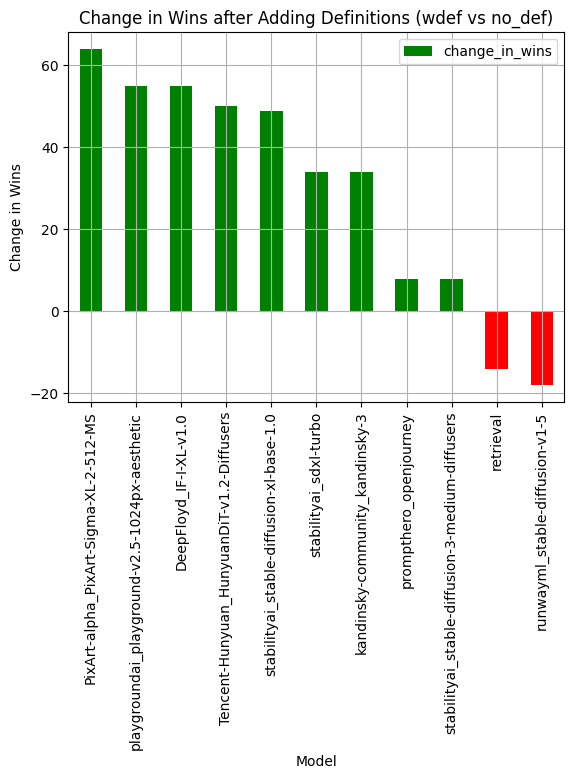

In [150]:

comparison.plot(x='model', y='change_in_wins', kind='bar', color=['green' if x > 0 else 'red' for x in comparison['change_in_wins']])
plt.title('Change in Wins after Adding Definitions (wdef vs no_def)')
plt.xlabel('Model')
plt.ylabel('Change in Wins')
plt.grid(True)
plt.show()


In [151]:
# GPT Version
gpt_def = pd.read_csv('../data/main_gpt4_def-2.csv')

for i, row in gpt_def.iterrows():
    if row['gpt4'] == 'no such image':
        if row['model_a'] == 'retrieval':
            gpt_def['gpt4'][i] = 'B'
        else:
            gpt_def['gpt4'][i] = 'A'

gpt_def['result'] = gpt_def['gpt4'].replace({'A': 0, 'B': 1, 'C': 2, 'D': 3})
gpt_def['result'][gpt_def['result'].isna()] = 3

gpt_nodef = pd.read_csv('../data/main_gpt4_nodef.csv')

for i, row in gpt_nodef.iterrows():
    if row['gpt4'] == 'no such image':
        if row['model_a'] == 'retrieval':
            gpt_nodef['gpt4'][i] = 'B'
        else:
            gpt_nodef['gpt4'][i] = 'A'

gpt_nodef['result'] = gpt_nodef['gpt4'].replace({'A': 0, 'B': 1, 'C': 2, 'D': 3})
gpt_nodef['result'][gpt_nodef['result'].isna()] = 3


/tmp/ipykernel_3712862/2797981623.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gpt_def['gpt4'][i] = 'A'
/tmp/ipykernel_3712862/2797981623.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gpt_def['gpt4'][i] = 'B'
/tmp/ipykernel_3712862/2797981623.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gpt_def['result'][gpt_def['result'].isna()] = 3
/tmp/ipykernel_3712862/2797981623.py:21: SettingWithCopyWarning: 
A value is tryin

In [152]:
wins_gpt_def = count_wins(gpt_def)
wins_gpt_nodef = count_wins(gpt_nodef)

In [167]:
reward_columns = {
    'stabilityai_sdxl-turbo': 'SDXL-turbo',
    'retrieval': 'Retrieval',
    'runwayml_stable-diffusion-v1-5': 'SD1.5',
    'Tencent-Hunyuan_HunyuanDiT-v1.2-Diffusers': 'HDiT',
    'playgroundai_playground-v2.5-1024px-aesthetic': 'Playground',
    'prompthero_openjourney': 'Openjourney',
    'kandinsky-community_kandinsky-3': 'Kandinsky3',
    'stabilityai_stable-diffusion-xl-base-1.0': 'SDXL',
    'PixArt-alpha_PixArt-Sigma-XL-2-512-MS': 'PixArt',
    'DeepFloyd_IF-I-XL-v1.0': 'DeepFloyd',
    'stabilityai_stable-diffusion-3-medium-diffusers': 'SD3'
}


comparison = pd.DataFrame({
    'model': list(set(wdef['model_a']).union(set(wdef['model_b']))),
    'wins_wdef': [wins_wdef.get(model, 0) for model in list(set(wdef['model_a']).union(set(wdef['model_b'])))],
    'wins_no_def': [wins_no_def.get(model, 0) for model in list(set(wdef['model_a']).union(set(wdef['model_b'])))],
    'wins_gpt_def': [wins_gpt_def.get(model, 0) for model in list(set(wdef['model_a']).union(set(wdef['model_b'])))],
    'wins_gpt_nodef': [wins_gpt_nodef.get(model, 0) for model in list(set(wdef['model_a']).union(set(wdef['model_b'])))]
})

# Calculate the change in wins for each comparison
comparison['change_wdef_vs_no_def'] = comparison['wins_wdef'] - comparison['wins_no_def']
comparison['change_gpt_def_vs_nodef'] = comparison['wins_gpt_def'] - comparison['wins_gpt_nodef']

comparison['model'] = comparison['model'].replace(reward_columns)


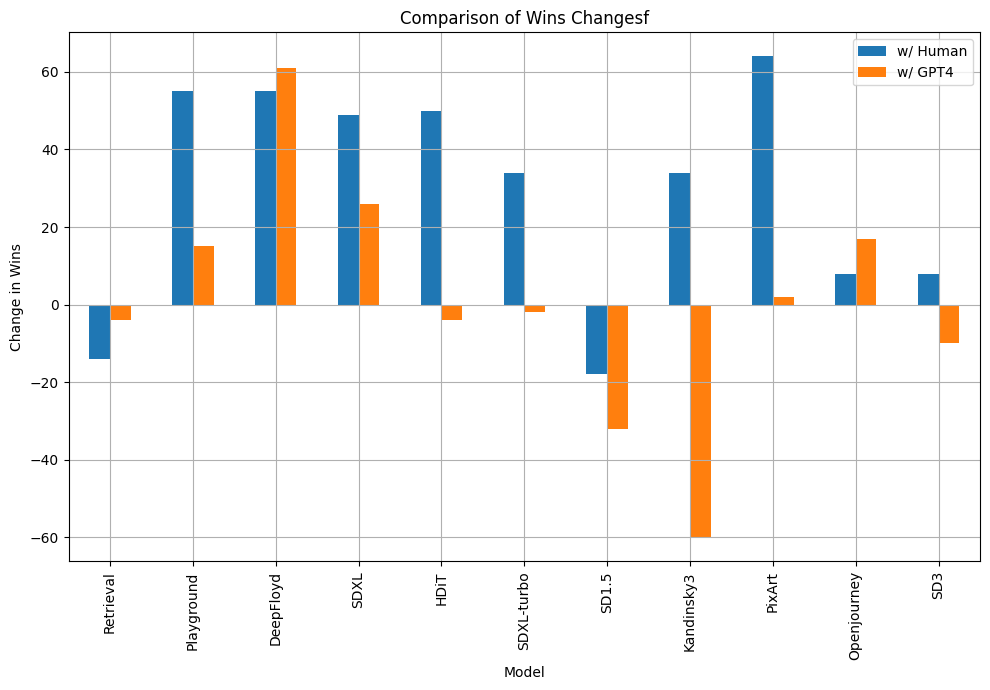

In [192]:
comparison.plot(x='model', y=['change_wdef_vs_no_def', 'change_gpt_def_vs_nodef'], kind='bar', figsize=(10, 7))

# Add labels and titles
plt.title('Comparison of Wins Changesf')
plt.xlabel('Model')
plt.ylabel('Change in Wins')
plt.legend(['w/ Human', 'w/ GPT4'], loc='upper right')
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()